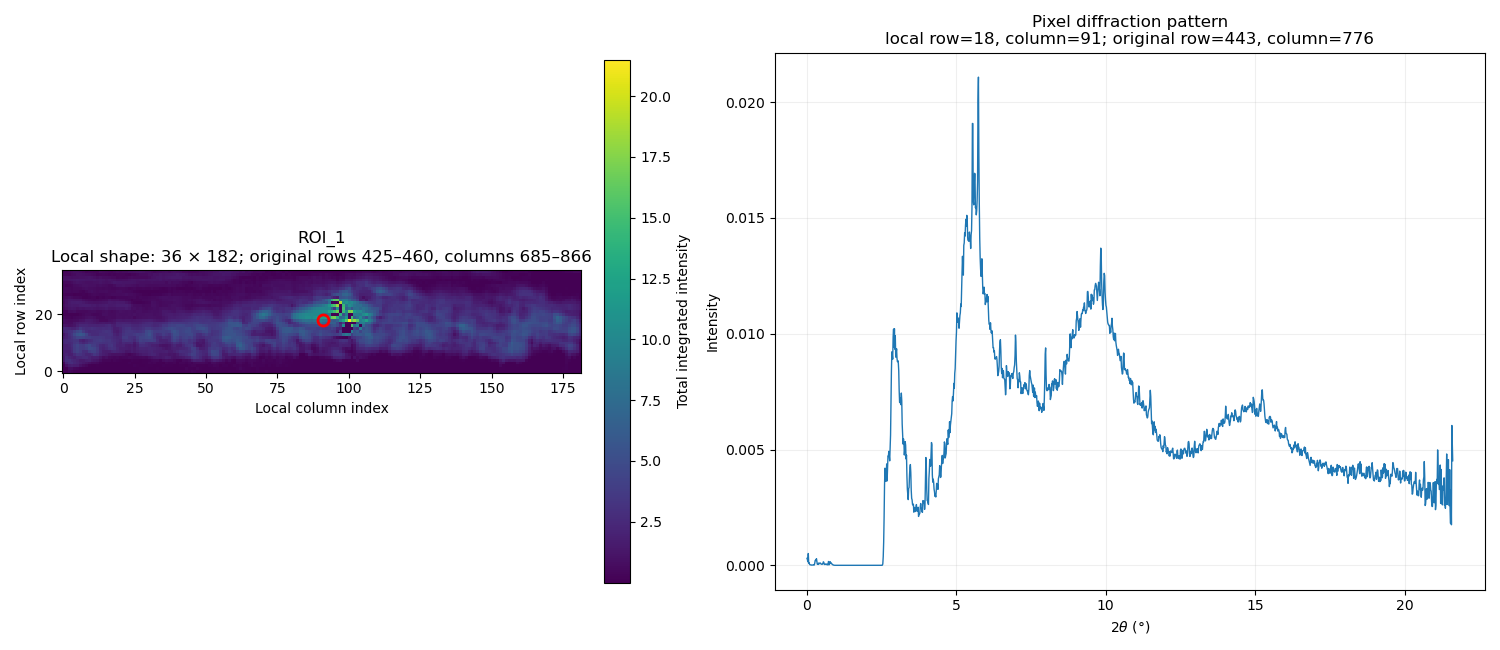

In [3]:
# ##############################################################
# CELL 1 — Imports
# ##############################################################

import os
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm, PowerNorm, Normalize
from matplotlib.gridspec import GridSpec

from scipy.ndimage import median_filter, gaussian_filter1d
from scipy.signal import find_peaks
from scipy.optimize import least_squares

from ipywidgets import (
    IntSlider, Dropdown, FloatText, Button, Checkbox,
    HBox, VBox, Label
)
from IPython.display import display

%matplotlib widget

from pathlib import Path
from matplotlib.widgets import RectangleSelector
from matplotlib.patches import Rectangle
from ipywidgets import (
    Dropdown,
    ToggleButtons,
    Checkbox,
    Button,
    HBox,
    VBox,
    HTML,
)
from IPython.display import display

# ==============================================================
# 1. Find saved ROI files
# ==============================================================

roi_folder = Path(
    "/home/esrf/tran/pigment"
)

roi_files = sorted(
    roi_folder.glob("*.npz")
)

if not roi_files:
    raise FileNotFoundError(
        f"No .npz files found in:\n{roi_folder}"
    )

# ==============================================================
# 2. Controls
# ==============================================================

roi_dropdown = Dropdown(
    options=[
        (file.name, index)
        for index, file in enumerate(roi_files)
    ],
    value=0,
    description="ROI:",
    layout={"width": "500px"},
)

mode_toggle = ToggleButtons(
    options=[
        "Click pixel",
        "Draw rectangle",
    ],
    value="Click pixel",
    description="Mode:",
)

rectangle_mode = Dropdown(
    options=[
        ("Mean pattern", "mean"),
        ("Summed pattern", "sum"),
    ],
    value="mean",
    description="Rectangle:",
)

log_checkbox = Checkbox(
    value=False,
    description="Log y-scale",
    indent=False,
)

previous_button = Button(
    description="Previous",
    icon="arrow-left",
)

next_button = Button(
    description="Next",
    icon="arrow-right",
)

clear_button = Button(
    description="Clear selection",
    icon="eraser",
)

roi_info = HTML()
selection_info = HTML()

# ==============================================================
# 3. Current ROI data
# ==============================================================

current = {
    "intensity": None,
    "two_theta": None,
    "roi_map": None,
    "roi_name": "",
    "bounds": None,
    "local_rows": None,
    "local_cols": None,
    "original_rows": None,
    "original_cols": None,
    "selection_type": None,
    "rectangle_bounds": None,
}

# ==============================================================
# 4. Load one saved ROI file
# ==============================================================

def load_roi_file(filepath):

    with np.load(
        filepath,
        allow_pickle=False,
    ) as data:

        intensity = np.asarray(
            data["intensity"]
        )

        two_theta = np.asarray(
            data["two_theta"]
        )

        if "total_intensity_roi" in data:

            roi_map = np.asarray(
                data["total_intensity_roi"],
                dtype=np.float64,
            )

        else:

            roi_map = np.nansum(
                intensity,
                axis=0,
            )

        if "roi_name" in data:

            roi_name = str(
                data["roi_name"]
            )

        else:

            roi_name = filepath.stem

        # Original-image ROI bounds
        if "roi_bounds_original" in data:

            bounds = np.asarray(
                data["roi_bounds_original"],
                dtype=int,
            )

        elif "roi_bounds_global" in data:

            bounds = np.asarray(
                data["roi_bounds_global"],
                dtype=int,
            )

        else:

            bounds = np.array(
                [
                    0,
                    roi_map.shape[0] - 1,
                    0,
                    roi_map.shape[1] - 1,
                ],
                dtype=int,
            )

        # Local row indices
        if "new_row_index" in data:

            local_rows = np.asarray(
                data["new_row_index"],
                dtype=int,
            )

        elif "local_row_index" in data:

            local_rows = np.asarray(
                data["local_row_index"],
                dtype=int,
            )

        else:

            local_rows = np.arange(
                roi_map.shape[0],
                dtype=int,
            )

        # Local column indices
        if "new_col_index" in data:

            local_cols = np.asarray(
                data["new_col_index"],
                dtype=int,
            )

        elif "local_col_index" in data:

            local_cols = np.asarray(
                data["local_col_index"],
                dtype=int,
            )

        else:

            local_cols = np.arange(
                roi_map.shape[1],
                dtype=int,
            )

        # Original row indices
        if "original_row_index" in data:

            original_rows = np.asarray(
                data["original_row_index"],
                dtype=int,
            )

        elif "global_row_index" in data:

            original_rows = np.asarray(
                data["global_row_index"],
                dtype=int,
            )

        else:

            original_rows = np.arange(
                bounds[0],
                bounds[1] + 1,
                dtype=int,
            )

        # Original column indices
        if "original_col_index" in data:

            original_cols = np.asarray(
                data["original_col_index"],
                dtype=int,
            )

        elif "global_col_index" in data:

            original_cols = np.asarray(
                data["global_col_index"],
                dtype=int,
            )

        else:

            original_cols = np.arange(
                bounds[2],
                bounds[3] + 1,
                dtype=int,
            )

    return {
        "intensity": intensity,
        "two_theta": two_theta,
        "roi_map": roi_map,
        "roi_name": roi_name,
        "bounds": bounds,
        "local_rows": local_rows,
        "local_cols": local_cols,
        "original_rows": original_rows,
        "original_cols": original_cols,
    }

# ==============================================================
# 5. Figure
# ==============================================================

plt.close("all")

fig, (ax_map, ax_pattern) = plt.subplots(
    1,
    2,
    figsize=(15, 6.5),
    gridspec_kw={
        "width_ratios": [1, 1.25],
    },
)

# ROI total-intensity map
roi_image = ax_map.imshow(
    np.zeros((2, 2)),
    cmap="viridis",
    origin="lower",
    aspect="equal",
    interpolation="nearest",
)

colorbar = fig.colorbar(
    roi_image,
    ax=ax_map,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Total integrated intensity"
)

ax_map.set_xlabel(
    "Local column index"
)

ax_map.set_ylabel(
    "Local row index"
)

# 1D diffraction pattern
pattern_line, = ax_pattern.plot(
    [],
    [],
    linewidth=1,
)

ax_pattern.set_xlabel(
    r"$2\theta$ (°)"
)

ax_pattern.set_ylabel(
    "Intensity"
)

ax_pattern.set_title(
    "Click a pixel or draw a rectangle"
)

ax_pattern.grid(alpha=0.2)

# Click marker
click_marker, = ax_map.plot(
    [],
    [],
    marker="o",
    markersize=8,
    markerfacecolor="none",
    markeredgecolor="red",
    markeredgewidth=2,
    linestyle="",
)

# Persistent rectangle display
rectangle_patch = Rectangle(
    (0, 0),
    0,
    0,
    fill=False,
    edgecolor="red",
    linewidth=2,
)

rectangle_patch.set_visible(False)
ax_map.add_patch(rectangle_patch)

fig.tight_layout()

# ==============================================================
# 6. Update diffraction-pattern axes
# ==============================================================

def update_pattern_axes(_=None):

    ax_pattern.set_yscale(
        "log"
        if log_checkbox.value
        else "linear"
    )

    ax_pattern.relim()
    ax_pattern.autoscale_view()

    fig.canvas.draw_idle()

# ==============================================================
# 7. Display one pixel pattern
# ==============================================================

def show_pixel_pattern(local_row, local_col):

    intensity = current["intensity"]

    if intensity is None:
        return

    height = intensity.shape[1]
    width = intensity.shape[2]

    if not (
        0 <= local_row < height
        and 0 <= local_col < width
    ):
        return

    pattern = intensity[
        :,
        local_row,
        local_col,
    ]

    original_row = current[
        "original_rows"
    ][local_row]

    original_col = current[
        "original_cols"
    ][local_col]

    current["selection_type"] = "pixel"
    current["rectangle_bounds"] = None

    click_marker.set_data(
        [local_col],
        [local_row],
    )

    rectangle_patch.set_visible(False)

    pattern_line.set_data(
        current["two_theta"],
        pattern,
    )

    ax_pattern.set_title(
        "Pixel diffraction pattern\n"
        f"local row={local_row}, column={local_col}; "
        f"original row={original_row}, column={original_col}"
    )

    selection_info.value = (
        f"<b>Selection:</b> one pixel<br>"
        f"<b>Local index:</b> "
        f"row {local_row}, column {local_col}<br>"
        f"<b>Original index:</b> "
        f"row {original_row}, column {original_col}"
    )

    update_pattern_axes()

# ==============================================================
# 8. Click-pixel handler
# ==============================================================

def on_map_click(event):

    if mode_toggle.value != "Click pixel":
        return

    if event.inaxes != ax_map:
        return

    if event.xdata is None or event.ydata is None:
        return

    local_col = int(
        round(event.xdata)
    )

    local_row = int(
        round(event.ydata)
    )

    show_pixel_pattern(
        local_row,
        local_col,
    )


fig.canvas.mpl_connect(
    "button_press_event",
    on_map_click,
)

# ==============================================================
# 9. Convert rectangle coordinates to local pixel bounds
# ==============================================================

def rectangle_bounds(x0, x1, y0, y1):

    intensity = current["intensity"]

    if intensity is None:
        return None

    height = intensity.shape[1]
    width = intensity.shape[2]

    c0, c1 = sorted([
        int(round(x0)),
        int(round(x1)),
    ])

    r0, r1 = sorted([
        int(round(y0)),
        int(round(y1)),
    ])

    c0 = max(
        0,
        min(c0, width - 1),
    )

    c1 = max(
        0,
        min(c1, width - 1),
    )

    r0 = max(
        0,
        min(r0, height - 1),
    )

    r1 = max(
        0,
        min(r1, height - 1),
    )

    return r0, r1, c0, c1

# ==============================================================
# 10. Display rectangle mean or summed pattern
# ==============================================================

def show_rectangle_pattern():

    bounds = current["rectangle_bounds"]
    intensity = current["intensity"]

    if bounds is None or intensity is None:
        return

    r0, r1, c0, c1 = bounds

    selected = intensity[
        :,
        r0:r1 + 1,
        c0:c1 + 1,
    ]

    if rectangle_mode.value == "mean":

        pattern = np.nanmean(
            selected,
            axis=(1, 2),
        )

        mode_text = "Mean"

    else:

        pattern = np.nansum(
            selected,
            axis=(1, 2),
        )

        mode_text = "Summed"

    number_of_pixels = (
        (r1 - r0 + 1)
        * (c1 - c0 + 1)
    )

    original_r0 = current[
        "original_rows"
    ][r0]

    original_r1 = current[
        "original_rows"
    ][r1]

    original_c0 = current[
        "original_cols"
    ][c0]

    original_c1 = current[
        "original_cols"
    ][c1]

    pattern_line.set_data(
        current["two_theta"],
        pattern,
    )

    ax_pattern.set_title(
        f"{mode_text} rectangle diffraction pattern\n"
        f"{number_of_pixels} selected pixels"
    )

    click_marker.set_data([], [])

    rectangle_patch.set_bounds(
        c0 - 0.5,
        r0 - 0.5,
        c1 - c0 + 1,
        r1 - r0 + 1,
    )

    rectangle_patch.set_visible(True)

    selection_info.value = (
        f"<b>Selection:</b> rectangle<br>"
        f"<b>Number of pixels:</b> {number_of_pixels}<br>"
        f"<b>Local rows:</b> {r0}–{r1}<br>"
        f"<b>Local columns:</b> {c0}–{c1}<br>"
        f"<b>Original rows:</b> "
        f"{original_r0}–{original_r1}<br>"
        f"<b>Original columns:</b> "
        f"{original_c0}–{original_c1}"
    )

    update_pattern_axes()

# ==============================================================
# 11. Rectangle-selection callback
# ==============================================================

def on_rectangle_select(eclick, erelease):

    if mode_toggle.value != "Draw rectangle":
        return

    if (
        eclick.inaxes != ax_map
        or erelease.inaxes != ax_map
    ):
        return

    if None in (
        eclick.xdata,
        eclick.ydata,
        erelease.xdata,
        erelease.ydata,
    ):
        return

    bounds = rectangle_bounds(
        eclick.xdata,
        erelease.xdata,
        eclick.ydata,
        erelease.ydata,
    )

    if bounds is None:
        return

    current["selection_type"] = "rectangle"
    current["rectangle_bounds"] = bounds

    show_rectangle_pattern()

# ==============================================================
# 12. Rectangle selector
# ==============================================================

selector = RectangleSelector(
    ax_map,
    on_rectangle_select,
    useblit=True,
    button=[1],
    minspanx=1,
    minspany=1,
    spancoords="data",
    interactive=False,
    props={
        "facecolor": "none",
        "edgecolor": "white",
        "linewidth": 1.5,
        "linestyle": "--",
    },
)

selector.set_active(False)


def change_mode(change):

    selector.set_active(
        change["new"] == "Draw rectangle"
    )


mode_toggle.observe(
    change_mode,
    names="value",
)

# ==============================================================
# 13. Clear current selection
# ==============================================================

def clear_selection(_=None):

    current["selection_type"] = None
    current["rectangle_bounds"] = None

    click_marker.set_data([], [])
    rectangle_patch.set_visible(False)

    pattern_line.set_data([], [])

    ax_pattern.set_title(
        "Click a pixel or draw a rectangle"
    )

    selection_info.value = ""

    try:
        selector.clear()
    except Exception:
        pass

    fig.canvas.draw_idle()

# ==============================================================
# 14. Load and display selected ROI
# ==============================================================

def plot_selected_roi(_=None):

    filepath = roi_files[
        roi_dropdown.value
    ]

    loaded = load_roi_file(
        filepath
    )

    current.update(loaded)

    roi_map = current["roi_map"]
    roi_name = current["roi_name"]
    bounds = current["bounds"]

    height, width = roi_map.shape

    roi_image.set_data(
        roi_map
    )

    roi_image.set_extent([
        -0.5,
        width - 0.5,
        -0.5,
        height - 0.5,
    ])

    finite = roi_map[
        np.isfinite(roi_map)
    ]

    if finite.size > 0:

        vmin = float(
            np.min(finite)
        )

        vmax = float(
            np.max(finite)
        )

        if vmax <= vmin:
            vmax = vmin + 1.0

    else:

        vmin = 0.0
        vmax = 1.0

    roi_image.set_clim(
        vmin,
        vmax,
    )

    colorbar.update_normal(
        roi_image
    )

    ax_map.set_xlim(
        -0.5,
        width - 0.5,
    )

    ax_map.set_ylim(
        -0.5,
        height - 0.5,
    )

    r0, r1, c0, c1 = bounds

    ax_map.set_title(
        f"{roi_name}\n"
        f"Local shape: {height} × {width}; "
        f"original rows {r0}–{r1}, "
        f"columns {c0}–{c1}"
    )

    roi_info.value = (
        f"<b>File:</b> {filepath.name}<br>"
        f"<b>Local rows:</b> "
        f"{current['local_rows'][0]}–"
        f"{current['local_rows'][-1]}<br>"
        f"<b>Local columns:</b> "
        f"{current['local_cols'][0]}–"
        f"{current['local_cols'][-1]}<br>"
        f"<b>Original rows:</b> {r0}–{r1}<br>"
        f"<b>Original columns:</b> {c0}–{c1}"
    )

    clear_selection()

    # Initially display the central pixel
    show_pixel_pattern(
        height // 2,
        width // 2,
    )

    fig.tight_layout()
    fig.canvas.draw_idle()

# ==============================================================
# 15. Previous and next ROI
# ==============================================================

def show_previous(_=None):

    roi_dropdown.value = (
        roi_dropdown.value - 1
    ) % len(roi_files)


def show_next(_=None):

    roi_dropdown.value = (
        roi_dropdown.value + 1
    ) % len(roi_files)


previous_button.on_click(
    show_previous
)

next_button.on_click(
    show_next
)

clear_button.on_click(
    clear_selection
)

roi_dropdown.observe(
    plot_selected_roi,
    names="value",
)

rectangle_mode.observe(
    lambda change: (
        show_rectangle_pattern()
        if current["selection_type"] == "rectangle"
        else None
    ),
    names="value",
)

log_checkbox.observe(
    update_pattern_axes,
    names="value",
)

# ==============================================================
# 16. Display
# ==============================================================

display(
    VBox([
        roi_dropdown,
        HBox([
            previous_button,
            next_button,
            mode_toggle,
        ]),
        HBox([
            rectangle_mode,
            log_checkbox,
            clear_button,
        ]),
        roi_info,
        selection_info,
    ])
)

plot_selected_roi()

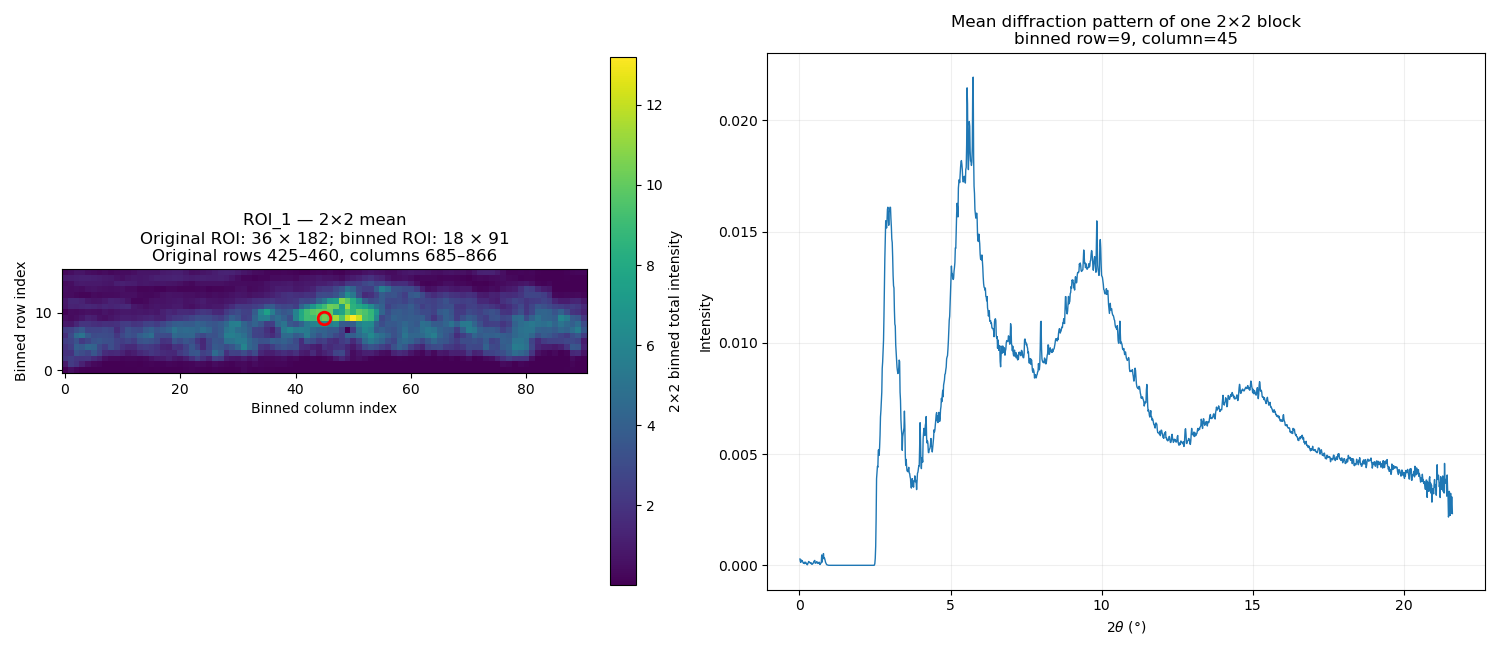

In [4]:
# CELL 9 — 2×2 spatial binning of saved ROIs
# Plot the binned map and inspect binned diffraction patterns
# by clicking one binned pixel or drawing a rectangle.
#
# Reuses the packages and roi_folder defined previously.

%matplotlib widget

plt.close("all")

roi_files = sorted(roi_folder.glob("*.npz"))

if not roi_files:
    raise FileNotFoundError(
        f"No .npz files found in:\n{roi_folder}"
    )

# ==============================================================
# 1. Controls
# ==============================================================

roi_dropdown = Dropdown(
    options=[
        (file.name, index)
        for index, file in enumerate(roi_files)
    ],
    value=0,
    description="ROI:",
    layout={"width": "500px"},
)

bin_mode = Dropdown(
    options=[
        ("Mean of each 2×2 block", "mean"),
        ("Sum of each 2×2 block", "sum"),
    ],
    value="mean",
    description="2×2 bin:",
    layout={"width": "300px"},
)

selection_mode = ToggleButtons(
    options=[
        "Click pixel",
        "Draw rectangle",
    ],
    value="Click pixel",
    description="Mode:",
)

rectangle_mode = Dropdown(
    options=[
        ("Mean pattern", "mean"),
        ("Summed pattern", "sum"),
    ],
    value="mean",
    description="Rectangle:",
)

log_checkbox = Checkbox(
    value=False,
    description="Log y-scale",
    indent=False,
)

previous_button = Button(
    description="Previous",
    icon="arrow-left",
)

next_button = Button(
    description="Next",
    icon="arrow-right",
)

clear_button = Button(
    description="Clear selection",
    icon="eraser",
)

roi_info = HTML()
selection_info = HTML()

# ==============================================================
# 2. Current data
# ==============================================================

current = {
    "raw_intensity": None,
    "binned_intensity": None,
    "two_theta": None,
    "raw_map": None,
    "binned_map": None,
    "roi_name": "",
    "bounds": None,
    "original_rows": None,
    "original_cols": None,
    "rectangle_bounds": None,
    "selection_type": None,
}

# ==============================================================
# 3. 2×2 binning functions
# ==============================================================

def bin_2x2_intensity(intensity, mode="mean"):
    """
    Input shape:
        (two_theta, row, column)

    Output shape:
        (two_theta, row/2, column/2)
    """

    n_theta, height, width = intensity.shape

    if height % 2 != 0 or width % 2 != 0:
        raise ValueError(
            f"ROI shape must be even, but received "
            f"{height} rows × {width} columns."
        )

    reshaped = intensity.reshape(
        n_theta,
        height // 2,
        2,
        width // 2,
        2,
    )

    if mode == "mean":
        return np.nanmean(
            reshaped,
            axis=(2, 4),
            dtype=np.float32,
        )

    return np.nansum(
        reshaped,
        axis=(2, 4),
        dtype=np.float32,
    )


def bin_2x2_map(roi_map, mode="mean"):
    """
    Input shape:
        (row, column)

    Output shape:
        (row/2, column/2)
    """

    height, width = roi_map.shape

    if height % 2 != 0 or width % 2 != 0:
        raise ValueError(
            f"ROI map shape must be even, but received "
            f"{height} rows × {width} columns."
        )

    reshaped = roi_map.reshape(
        height // 2,
        2,
        width // 2,
        2,
    )

    if mode == "mean":
        return np.nanmean(
            reshaped,
            axis=(1, 3),
            dtype=np.float32,
        )

    return np.nansum(
        reshaped,
        axis=(1, 3),
        dtype=np.float32,
    )

# ==============================================================
# 4. Load saved ROI
# ==============================================================

def load_roi_file(filepath):

    with np.load(
        filepath,
        allow_pickle=False,
    ) as data:

        raw_intensity = np.asarray(
            data["intensity"],
            dtype=np.float32,
        )

        two_theta = np.asarray(
            data["two_theta"],
            dtype=np.float64,
        )

        if "total_intensity_roi" in data:
            raw_map = np.asarray(
                data["total_intensity_roi"],
                dtype=np.float32,
            )
        else:
            raw_map = np.nansum(
                raw_intensity,
                axis=0,
                dtype=np.float32,
            )

        if "roi_name" in data:
            roi_name = str(data["roi_name"])
        else:
            roi_name = filepath.stem

        if "roi_bounds_original" in data:
            bounds = np.asarray(
                data["roi_bounds_original"],
                dtype=int,
            )
        elif "roi_bounds_global" in data:
            bounds = np.asarray(
                data["roi_bounds_global"],
                dtype=int,
            )
        else:
            bounds = np.array(
                [
                    0,
                    raw_map.shape[0] - 1,
                    0,
                    raw_map.shape[1] - 1,
                ],
                dtype=int,
            )

        if "original_row_index" in data:
            original_rows = np.asarray(
                data["original_row_index"],
                dtype=int,
            )
        elif "global_row_index" in data:
            original_rows = np.asarray(
                data["global_row_index"],
                dtype=int,
            )
        else:
            original_rows = np.arange(
                bounds[0],
                bounds[1] + 1,
                dtype=int,
            )

        if "original_col_index" in data:
            original_cols = np.asarray(
                data["original_col_index"],
                dtype=int,
            )
        elif "global_col_index" in data:
            original_cols = np.asarray(
                data["global_col_index"],
                dtype=int,
            )
        else:
            original_cols = np.arange(
                bounds[2],
                bounds[3] + 1,
                dtype=int,
            )

    return {
        "raw_intensity": raw_intensity,
        "two_theta": two_theta,
        "raw_map": raw_map,
        "roi_name": roi_name,
        "bounds": bounds,
        "original_rows": original_rows,
        "original_cols": original_cols,
    }

# ==============================================================
# 5. Figure
# ==============================================================

fig, (ax_map, ax_pattern) = plt.subplots(
    1,
    2,
    figsize=(15, 6.5),
    gridspec_kw={
        "width_ratios": [1, 1.25],
    },
)

binned_image = ax_map.imshow(
    np.zeros((2, 2)),
    cmap="viridis",
    origin="lower",
    aspect="equal",
    interpolation="nearest",
)

colorbar = fig.colorbar(
    binned_image,
    ax=ax_map,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "2×2 binned total intensity"
)

ax_map.set_xlabel(
    "Binned column index"
)

ax_map.set_ylabel(
    "Binned row index"
)

pattern_line, = ax_pattern.plot(
    [],
    [],
    linewidth=1,
)

ax_pattern.set_xlabel(
    r"$2\theta$ (°)"
)

ax_pattern.set_ylabel(
    "Intensity"
)

ax_pattern.set_title(
    "Click a binned pixel or draw a rectangle"
)

ax_pattern.grid(alpha=0.2)

click_marker, = ax_map.plot(
    [],
    [],
    marker="o",
    markersize=9,
    markerfacecolor="none",
    markeredgecolor="red",
    markeredgewidth=2,
    linestyle="",
)

rectangle_patch = Rectangle(
    (0, 0),
    0,
    0,
    fill=False,
    edgecolor="red",
    linewidth=2,
)

rectangle_patch.set_visible(False)
ax_map.add_patch(rectangle_patch)

fig.tight_layout()

# ==============================================================
# 6. Pattern-axis update
# ==============================================================

def update_pattern_axes(_=None):

    ax_pattern.set_yscale(
        "log"
        if log_checkbox.value
        else "linear"
    )

    ax_pattern.relim()
    ax_pattern.autoscale_view()

    fig.canvas.draw_idle()

# ==============================================================
# 7. Display one 2×2 binned pixel
# ==============================================================

def show_binned_pixel(binned_row, binned_col):

    intensity = current["binned_intensity"]

    if intensity is None:
        return

    binned_height = intensity.shape[1]
    binned_width = intensity.shape[2]

    if not (
        0 <= binned_row < binned_height
        and 0 <= binned_col < binned_width
    ):
        return

    pattern = intensity[
        :,
        binned_row,
        binned_col,
    ]

    # Local unbinned indices represented by this 2×2 block
    local_r0 = 2 * binned_row
    local_r1 = local_r0 + 1

    local_c0 = 2 * binned_col
    local_c1 = local_c0 + 1

    # Corresponding original-image indices
    original_r0 = current[
        "original_rows"
    ][local_r0]

    original_r1 = current[
        "original_rows"
    ][local_r1]

    original_c0 = current[
        "original_cols"
    ][local_c0]

    original_c1 = current[
        "original_cols"
    ][local_c1]

    current["selection_type"] = "pixel"
    current["rectangle_bounds"] = None

    click_marker.set_data(
        [binned_col],
        [binned_row],
    )

    rectangle_patch.set_visible(False)

    pattern_line.set_data(
        current["two_theta"],
        pattern,
    )

    operation = (
        "Mean"
        if bin_mode.value == "mean"
        else "Sum"
    )

    ax_pattern.set_title(
        f"{operation} diffraction pattern of one 2×2 block\n"
        f"binned row={binned_row}, column={binned_col}"
    )

    selection_info.value = (
        f"<b>Binned index:</b> "
        f"row {binned_row}, column {binned_col}<br>"
        f"<b>Local pixels:</b> "
        f"rows {local_r0}–{local_r1}, "
        f"columns {local_c0}–{local_c1}<br>"
        f"<b>Original pixels:</b> "
        f"rows {original_r0}–{original_r1}, "
        f"columns {original_c0}–{original_c1}"
    )

    update_pattern_axes()

# ==============================================================
# 8. Click handler
# ==============================================================

def on_map_click(event):

    if selection_mode.value != "Click pixel":
        return

    if event.inaxes != ax_map:
        return

    if event.xdata is None or event.ydata is None:
        return

    binned_col = int(round(event.xdata))
    binned_row = int(round(event.ydata))

    show_binned_pixel(
        binned_row,
        binned_col,
    )


fig.canvas.mpl_connect(
    "button_press_event",
    on_map_click,
)

# ==============================================================
# 9. Rectangle bounds
# ==============================================================

def get_rectangle_bounds(x0, x1, y0, y1):

    intensity = current["binned_intensity"]

    if intensity is None:
        return None

    height = intensity.shape[1]
    width = intensity.shape[2]

    c0, c1 = sorted([
        int(round(x0)),
        int(round(x1)),
    ])

    r0, r1 = sorted([
        int(round(y0)),
        int(round(y1)),
    ])

    c0 = max(0, min(c0, width - 1))
    c1 = max(0, min(c1, width - 1))

    r0 = max(0, min(r0, height - 1))
    r1 = max(0, min(r1, height - 1))

    return r0, r1, c0, c1

# ==============================================================
# 10. Display rectangle pattern
# ==============================================================

def show_rectangle_pattern():

    bounds = current["rectangle_bounds"]
    intensity = current["binned_intensity"]

    if bounds is None or intensity is None:
        return

    r0, r1, c0, c1 = bounds

    selected = intensity[
        :,
        r0:r1 + 1,
        c0:c1 + 1,
    ]

    if rectangle_mode.value == "mean":

        pattern = np.nanmean(
            selected,
            axis=(1, 2),
        )

        mode_text = "Mean"

    else:

        pattern = np.nansum(
            selected,
            axis=(1, 2),
        )

        mode_text = "Summed"

    number_of_binned_pixels = (
        (r1 - r0 + 1)
        * (c1 - c0 + 1)
    )

    number_of_original_pixels = (
        4 * number_of_binned_pixels
    )

    # Convert binned bounds back to local unbinned bounds
    local_r0 = 2 * r0
    local_r1 = 2 * r1 + 1

    local_c0 = 2 * c0
    local_c1 = 2 * c1 + 1

    original_r0 = current[
        "original_rows"
    ][local_r0]

    original_r1 = current[
        "original_rows"
    ][local_r1]

    original_c0 = current[
        "original_cols"
    ][local_c0]

    original_c1 = current[
        "original_cols"
    ][local_c1]

    pattern_line.set_data(
        current["two_theta"],
        pattern,
    )

    ax_pattern.set_title(
        f"{mode_text} rectangle pattern\n"
        f"{number_of_binned_pixels} binned pixels "
        f"({number_of_original_pixels} original pixels)"
    )

    click_marker.set_data([], [])

    rectangle_patch.set_bounds(
        c0 - 0.5,
        r0 - 0.5,
        c1 - c0 + 1,
        r1 - r0 + 1,
    )

    rectangle_patch.set_visible(True)

    selection_info.value = (
        f"<b>Binned rows:</b> {r0}–{r1}<br>"
        f"<b>Binned columns:</b> {c0}–{c1}<br>"
        f"<b>Local original rows:</b> "
        f"{local_r0}–{local_r1}<br>"
        f"<b>Local original columns:</b> "
        f"{local_c0}–{local_c1}<br>"
        f"<b>Original image rows:</b> "
        f"{original_r0}–{original_r1}<br>"
        f"<b>Original image columns:</b> "
        f"{original_c0}–{original_c1}<br>"
        f"<b>Original pixel count:</b> "
        f"{number_of_original_pixels}"
    )

    update_pattern_axes()

# ==============================================================
# 11. Rectangle selector
# ==============================================================

def on_rectangle_select(eclick, erelease):

    if selection_mode.value != "Draw rectangle":
        return

    if (
        eclick.inaxes != ax_map
        or erelease.inaxes != ax_map
    ):
        return

    if None in (
        eclick.xdata,
        eclick.ydata,
        erelease.xdata,
        erelease.ydata,
    ):
        return

    bounds = get_rectangle_bounds(
        eclick.xdata,
        erelease.xdata,
        eclick.ydata,
        erelease.ydata,
    )

    if bounds is None:
        return

    current["selection_type"] = "rectangle"
    current["rectangle_bounds"] = bounds

    show_rectangle_pattern()


selector = RectangleSelector(
    ax_map,
    on_rectangle_select,
    useblit=True,
    button=[1],
    minspanx=1,
    minspany=1,
    spancoords="data",
    interactive=False,
    props={
        "facecolor": "none",
        "edgecolor": "white",
        "linewidth": 1.5,
        "linestyle": "--",
    },
)

selector.set_active(False)


def change_selection_mode(change):

    selector.set_active(
        change["new"] == "Draw rectangle"
    )


selection_mode.observe(
    change_selection_mode,
    names="value",
)

# ==============================================================
# 12. Clear selection
# ==============================================================

def clear_selection(_=None):

    current["selection_type"] = None
    current["rectangle_bounds"] = None

    click_marker.set_data([], [])
    rectangle_patch.set_visible(False)

    pattern_line.set_data([], [])

    ax_pattern.set_title(
        "Click a binned pixel or draw a rectangle"
    )

    selection_info.value = ""

    try:
        selector.clear()
    except Exception:
        pass

    fig.canvas.draw_idle()

# ==============================================================
# 13. Load, bin and display selected ROI
# ==============================================================

def plot_selected_roi(_=None):

    filepath = roi_files[
        roi_dropdown.value
    ]

    loaded = load_roi_file(filepath)

    current.update(loaded)

    raw_intensity = current["raw_intensity"]
    raw_map = current["raw_map"]

    raw_height = raw_intensity.shape[1]
    raw_width = raw_intensity.shape[2]

    if raw_height % 2 != 0 or raw_width % 2 != 0:
        raise ValueError(
            f"{filepath.name} has an odd ROI shape: "
            f"{raw_height} × {raw_width}."
        )

    current["binned_intensity"] = bin_2x2_intensity(
        raw_intensity,
        mode=bin_mode.value,
    )

    current["binned_map"] = bin_2x2_map(
        raw_map,
        mode=bin_mode.value,
    )

    binned_map = current["binned_map"]
    binned_height, binned_width = binned_map.shape

    binned_image.set_data(
        binned_map
    )

    binned_image.set_extent([
        -0.5,
        binned_width - 0.5,
        -0.5,
        binned_height - 0.5,
    ])

    finite = binned_map[
        np.isfinite(binned_map)
    ]

    if finite.size:

        vmin = float(np.min(finite))
        vmax = float(np.max(finite))

        if vmax <= vmin:
            vmax = vmin + 1.0

    else:

        vmin = 0.0
        vmax = 1.0

    binned_image.set_clim(
        vmin,
        vmax,
    )

    colorbar.update_normal(
        binned_image
    )

    ax_map.set_xlim(
        -0.5,
        binned_width - 0.5,
    )

    ax_map.set_ylim(
        -0.5,
        binned_height - 0.5,
    )

    r0, r1, c0, c1 = current["bounds"]

    operation = (
        "2×2 mean"
        if bin_mode.value == "mean"
        else "2×2 sum"
    )

    ax_map.set_title(
        f"{current['roi_name']} — {operation}\n"
        f"Original ROI: {raw_height} × {raw_width}; "
        f"binned ROI: {binned_height} × {binned_width}\n"
        f"Original rows {r0}–{r1}, "
        f"columns {c0}–{c1}"
    )

    roi_info.value = (
        f"<b>File:</b> {filepath.name}<br>"
        f"<b>Original ROI shape:</b> "
        f"{raw_height} × {raw_width}<br>"
        f"<b>2×2 binned shape:</b> "
        f"{binned_height} × {binned_width}<br>"
        f"<b>Binning:</b> {operation}"
    )

    clear_selection()

    show_binned_pixel(
        binned_height // 2,
        binned_width // 2,
    )

    fig.tight_layout()
    fig.canvas.draw_idle()

# ==============================================================
# 14. Navigation and observers
# ==============================================================

def show_previous(_=None):

    roi_dropdown.value = (
        roi_dropdown.value - 1
    ) % len(roi_files)


def show_next(_=None):

    roi_dropdown.value = (
        roi_dropdown.value + 1
    ) % len(roi_files)


previous_button.on_click(
    show_previous
)

next_button.on_click(
    show_next
)

clear_button.on_click(
    clear_selection
)

roi_dropdown.observe(
    plot_selected_roi,
    names="value",
)

bin_mode.observe(
    plot_selected_roi,
    names="value",
)

rectangle_mode.observe(
    lambda change: (
        show_rectangle_pattern()
        if current["selection_type"] == "rectangle"
        else None
    ),
    names="value",
)

log_checkbox.observe(
    update_pattern_axes,
    names="value",
)

# ==============================================================
# 15. Display
# ==============================================================

display(
    VBox([
        roi_dropdown,
        HBox([
            previous_button,
            next_button,
            bin_mode,
        ]),
        HBox([
            selection_mode,
            rectangle_mode,
            log_checkbox,
            clear_button,
        ]),
        roi_info,
        selection_info,
    ])
)

plot_selected_roi()

In [5]:
# CELL 10 — Export all 2×2 grouped ROI patterns as .xy files
#
# Reuses:
# roi_folder, roi_files, load_roi_file,
# bin_2x2_intensity, bin_mode, np, Path

prefix = "pap"
bin_size = 2

output_folder = (
    roi_folder
    / "grouped_data_id11"
)

output_folder.mkdir(
    parents=True,
    exist_ok=True,
)

# Uses the currently selected binning mode:
# "mean" or "sum"
export_mode = bin_mode.value

total_saved = 0

for roi_number, filepath in enumerate(
    roi_files,
    start=1,
):

    loaded = load_roi_file(filepath)

    raw_intensity = loaded["raw_intensity"]
    two_theta = loaded["two_theta"]
    roi_name = loaded["roi_name"]

    # Shape before binning:
    # (n_points, rows, columns)
    binned_intensity = bin_2x2_intensity(
        raw_intensity,
        mode=export_mode,
    )

    n_points, new_rows, new_cols = (
        binned_intensity.shape
    )

    # Safe ROI folder name
    roi_tag = "".join(
        character
        if character.isalnum()
        or character in "-_"
        else "_"
        for character in roi_name
    ).strip("_")

    roi_output_folder = (
        output_folder
        / f"{roi_number:02d}_{roi_tag}_{export_mode}"
    )

    roi_output_folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    for r in range(new_rows):

        for c in range(new_cols):

            y = binned_intensity[
                :,
                r,
                c,
            ]

            xy = np.column_stack([
                two_theta,
                y,
            ])

            idx = (
                r * new_cols
                + c
            )

            filename = (
                f"{prefix}_bin{bin_size}x{bin_size}"
                f"_r{r:03d}_c{c:03d}"
                f"_idx{idx:05d}.xy"
            )

            output_path = (
                roi_output_folder
                / filename
            )

            # Two columns only:
            # 2theta   intensity
            # No header and no column names
            np.savetxt(
                output_path,
                xy,
                fmt="%.8e",
                comments="",
            )

            total_saved += 1

    print(
        f"{roi_name}: saved "
        f"{new_rows * new_cols} files "
        f"({new_rows} × {new_cols})"
    )

print("\nDone.")
print(f"Binning mode: {export_mode}")
print(f"Total files saved: {total_saved}")
print(f"Output folder:\n{output_folder}")

ROI_1: saved 1638 files (18 × 91)
ROI_2: saved 1638 files (18 × 91)

Done.
Binning mode: mean
Total files saved: 3276
Output folder:
/home/esrf/tran/pigment/grouped_data_id11


In [1]:
# CELL 11 — Export all original, ungrouped ROI patterns as .xy files
#
# Reuses:
# roi_folder, roi_files, load_roi_file, np, Path

prefix = "pap"

output_folder = (
    roi_folder
    / "ungrouped_data_id11"
)

output_folder.mkdir(
    parents=True,
    exist_ok=True,
)

total_saved = 0

for roi_number, filepath in enumerate(
    roi_files,
    start=1,
):

    loaded = load_roi_file(filepath)

    # Shape:
    # (n_two_theta, rows, columns)
    raw_intensity = loaded["raw_intensity"]
    two_theta = loaded["two_theta"]
    roi_name = loaded["roi_name"]

    n_points, n_rows_roi, n_cols_roi = (
        raw_intensity.shape
    )

    # Safe ROI folder name
    roi_tag = "".join(
        character
        if character.isalnum()
        or character in "-_"
        else "_"
        for character in roi_name
    ).strip("_")

    roi_output_folder = (
        output_folder
        / f"{roi_number:02d}_{roi_tag}"
    )

    roi_output_folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    for r in range(n_rows_roi):

        for c in range(n_cols_roi):

            y = raw_intensity[
                :,
                r,
                c,
            ]

            xy = np.column_stack([
                two_theta,
                y,
            ])

            idx = (
                r * n_cols_roi
                + c
            )

            filename = (
                f"{prefix}_raw"
                f"_r{r:03d}_c{c:03d}"
                f"_idx{idx:05d}.xy"
            )

            output_path = (
                roi_output_folder
                / filename
            )

            # Two numerical columns only:
            # 2theta  intensity
            # No header or column names
            np.savetxt(
                output_path,
                xy,
                fmt="%.8e",
                comments="",
            )

            total_saved += 1

    print(
        f"{roi_name}: saved "
        f"{n_rows_roi * n_cols_roi} files "
        f"({n_rows_roi} × {n_cols_roi})"
    )

print("\nDone.")
print("Data: original, not grouped")
print(f"Total files saved: {total_saved}")
print(f"Output folder:\n{output_folder}")

NameError: name 'discover_roi_files' is not defined